# MultiHeirtt Corpus Preprocessing for Better Retrieval

**Mục tiêu:** Chuyển đổi corpus MultiHeirtt thành format dễ hiểu hơn cho embedding models.

**Vấn đề từ phân tích:**
- 50.3% queries có NDCG=0 (hoàn toàn thất bại)
- Tables trong corpus có format markdown khó match với queries
- Vocabulary mismatch giữa query và documents

**Giải pháp:**
1. **Linearize tables** - Chuyển bảng thành câu văn tự nhiên
2. **Row-level chunking** - Tách từng dòng bảng thành documents riêng
3. **Add context** - Thêm ngữ cảnh từ title/surrounding text

## 1. Setup

In [1]:
import json
import re
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from tqdm.auto import tqdm

# Paths
BASE_DIR = Path("../..")
DATA_DIR = BASE_DIR / "data"
CORPUS_FILE = DATA_DIR / "multiheirtt_corpus.jsonl" / "corpus.jsonl"
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"✅ Corpus file: {CORPUS_FILE}")
print(f"✅ Output dir: {OUTPUT_DIR}")

✅ Corpus file: ..\..\data\multiheirtt_corpus.jsonl\corpus.jsonl
✅ Output dir: output


## 2. Load Original Corpus

In [2]:
def load_corpus(filepath: Path) -> Dict[str, Dict]:
    """Load corpus from JSONL file"""
    corpus = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            corpus[data['_id']] = {
                'title': data.get('title', ''),
                'text': data.get('text', '')
            }
    return corpus

# Load corpus
corpus = load_corpus(CORPUS_FILE)
print(f"✅ Loaded {len(corpus)} documents")

# Show sample
sample_id = list(corpus.keys())[0]
print(f"\n📄 Sample document ({sample_id}):")
print(corpus[sample_id]['text'][:500])

✅ Loaded 10475 documents

📄 Sample document (d8e4ea4ac):
|  | Years Ended December 31, |
|  | 2006 | 2005 |
|  | (In millions) |
| Investment return | $192 | $-26 |
| Expense | 45 | 11 |
| In-force/Persistency | -7 | -33 |
| Policyholder dividends and other | -39 | -11 |
| Total | $191 | $-59 |
As of December 31, 2006 and 2005, DAC and VOBA for the Individual segment were $14.0 billion and $13.5 billion, respectively, and for the total Company were $20.8 billion and $19.7 billion, respectively.
Goodwill Goodwill is the excess of cost over the fair val


## 3. Table Detection & Parsing Functions

In [3]:
def detect_markdown_tables(text: str) -> List[Tuple[str, int, int]]:
    """
    Detect markdown tables in text.
    Returns: List of (table_text, start_line, end_line)
    """
    tables = []
    lines = text.split('\n')
    
    i = 0
    while i < len(lines):
        line = lines[i]
        
        # Detect table row (has | separators)
        if '|' in line and line.count('|') >= 2:
            table_start = i
            table_lines = []
            
            # Collect all consecutive table lines
            while i < len(lines) and '|' in lines[i]:
                table_lines.append(lines[i])
                i += 1
            
            if len(table_lines) >= 2:  # At least 2 rows
                table_text = '\n'.join(table_lines)
                tables.append((table_text, table_start, i))
            continue
        
        i += 1
    
    return tables


def parse_markdown_table(table_text: str) -> Optional[Dict]:
    """
    Parse markdown table into structured format.
    Returns: {headers: [[...]], data: [[...]], num_cols, num_rows}
    """
    lines = [l.strip() for l in table_text.split('\n') if l.strip()]
    
    if len(lines) < 2:
        return None
    
    rows = []
    for line in lines:
        # Skip separator lines (---)
        if re.match(r'^\|?\s*[-:]+\s*\|', line):
            continue
        
        # Split by |
        cells = [c.strip() for c in line.split('|')]
        # Remove empty first/last cells
        if cells and not cells[0]:
            cells = cells[1:]
        if cells and not cells[-1]:
            cells = cells[:-1]
        
        if cells:
            rows.append(cells)
    
    if not rows:
        return None
    
    # Detect headers vs data rows
    header_rows = []
    data_rows = []
    
    for i, row in enumerate(rows):
        # Count numeric cells
        has_currency = any(re.search(r'[\$£€¥]', c) for c in row)
        has_numbers = any(re.search(r'\d{2,}', c) for c in row)
        is_year_row = any(re.match(r'^(19|20)\d{2}$', c.strip()) for c in row)
        is_unit_row = any('million' in c.lower() or 'thousand' in c.lower() for c in row)
        
        # Header if in first 3 rows and looks like header
        is_header = (
            i < 3 and 
            (is_year_row or is_unit_row or not (has_currency and has_numbers))
        )
        
        if is_header:
            header_rows.append(row)
        else:
            data_rows.append(row)
    
    # Fallback
    if not header_rows and rows:
        header_rows = [rows[0]]
        data_rows = rows[1:]
    
    return {
        'headers': header_rows,
        'data': data_rows,
        'num_cols': len(rows[0]) if rows else 0,
        'num_rows': len(data_rows)
    }


# Test
sample_table = """| | Years Ended December 31, |
| | 2006 | 2005 |
| | (In millions) |
| Investment return | $192 | $-26 |
| Expense | 45 | 11 |"""

parsed = parse_markdown_table(sample_table)
print("Headers:", parsed['headers'])
print("Data:", parsed['data'])

Headers: [['', 'Years Ended December 31,'], ['', '2006', '2005'], ['', '(In millions)']]
Data: [['Investment return', '$192', '$-26'], ['Expense', '45', '11']]


## 4. Table Linearization Functions

Chuyển bảng thành câu văn tự nhiên để embedding model hiểu được.

In [4]:
def build_column_headers(header_rows: List[List[str]], num_cols: int) -> List[str]:
    """
    Build column headers from multiple header rows.
    E.g., ['Years Ended December 31, - 2006', 'Years Ended December 31, - 2005']
    """
    col_headers = ['' for _ in range(num_cols)]
    
    for row in header_rows:
        for i, cell in enumerate(row):
            if i < num_cols and cell.strip():
                if col_headers[i]:
                    col_headers[i] += ' - ' + cell.strip()
                else:
                    col_headers[i] = cell.strip()
    
    # Clean up parenthetical units like "(In millions)"
    cleaned = []
    for h in col_headers:
        # Remove standalone unit rows
        if re.match(r'^\s*\(.*\)\s*$', h):
            cleaned.append('')
        else:
            cleaned.append(h)
    
    return cleaned


def linearize_table(parsed: Dict) -> str:
    """
    Convert parsed table to natural language sentences.
    
    Input: {headers: [[...]], data: [[...]]}
    Output: "Row Label: Column1=Value1, Column2=Value2. ..."
    """
    if not parsed or not parsed['data']:
        return ""
    
    headers = parsed['headers']
    data = parsed['data']
    num_cols = parsed['num_cols']
    
    # Build column headers
    col_headers = build_column_headers(headers, num_cols)
    
    sentences = []
    
    for row in data:
        if not row:
            continue
        
        row_label = row[0].strip() if row else ""
        values = []
        
        for i, cell in enumerate(row[1:], 1):
            if i < len(col_headers) and col_headers[i] and cell.strip():
                values.append(f"{col_headers[i]}={cell.strip()}")
            elif cell.strip():
                values.append(cell.strip())
        
        if row_label and values:
            sentence = f"{row_label}: {', '.join(values)}"
            sentences.append(sentence)
    
    return ". ".join(sentences)


def linearize_row(row: List[str], col_headers: List[str]) -> str:
    """
    Convert a single table row to natural language.
    """
    if not row:
        return ""
    
    row_label = row[0].strip()
    values = []
    
    for i, cell in enumerate(row[1:], 1):
        if i < len(col_headers) and col_headers[i] and cell.strip():
            values.append(f"{col_headers[i]} = {cell.strip()}")
        elif cell.strip():
            values.append(cell.strip())
    
    if row_label and values:
        return f"{row_label}: {', '.join(values)}"
    return ""


# Test linearization
linearized = linearize_table(parsed)
print("\n📝 Linearized table:")
print(linearized)


📝 Linearized table:
Investment return: Years Ended December 31, - 2006 - (In millions)=$192, $-26. Expense: Years Ended December 31, - 2006 - (In millions)=45, 11


## 5. Document Preprocessing Pipeline

In [5]:
def preprocess_document(doc_id: str, doc: Dict, mode: str = 'linearized') -> List[Dict]:
    """
    Preprocess a single document.
    
    Modes:
    - 'linearized': Replace tables with linearized text (default)
    - 'augmented': Keep original + add linearized versions
    - 'row_chunks': Create separate documents for each table row
    
    Returns: List of processed documents
    """
    text = doc['text']
    title = doc.get('title', '')
    
    # Detect tables
    tables = detect_markdown_tables(text)
    
    # If no tables, return original
    if not tables:
        return [{
            '_id': doc_id,
            'title': title,
            'text': text,
            'type': 'text_only'
        }]
    
    results = []
    
    if mode == 'linearized':
        # Replace tables with linearized versions
        new_text = text
        offset = 0
        
        lines = text.split('\n')
        new_lines = lines.copy()
        
        for table_text, start, end in tables:
            parsed = parse_markdown_table(table_text)
            if parsed:
                linearized = linearize_table(parsed)
                # Replace table lines with linearized text
                new_lines[start:end] = [linearized]
        
        results.append({
            '_id': doc_id,
            'title': title,
            'text': '\n'.join(new_lines),
            'type': 'linearized'
        })
    
    elif mode == 'augmented':
        # Keep original
        results.append({
            '_id': doc_id,
            'title': title,
            'text': text,
            'type': 'original'
        })
        
        # Add linearized tables as separate documents
        for i, (table_text, start, end) in enumerate(tables):
            parsed = parse_markdown_table(table_text)
            if parsed:
                linearized = linearize_table(parsed)
                if linearized:
                    results.append({
                        '_id': f"{doc_id}_table_{i}",
                        'title': title,
                        'text': linearized,
                        'type': 'linearized_table',
                        'parent_id': doc_id
                    })
    
    elif mode == 'row_chunks':
        # Keep original
        results.append({
            '_id': doc_id,
            'title': title,
            'text': text,
            'type': 'original'
        })
        
        # Create separate documents for each table row
        for i, (table_text, start, end) in enumerate(tables):
            parsed = parse_markdown_table(table_text)
            if parsed:
                col_headers = build_column_headers(
                    parsed['headers'], 
                    parsed['num_cols']
                )
                
                for j, row in enumerate(parsed['data']):
                    row_text = linearize_row(row, col_headers)
                    if row_text:
                        results.append({
                            '_id': f"{doc_id}_table_{i}_row_{j}",
                            'title': title,
                            'text': row_text,
                            'type': 'table_row',
                            'parent_id': doc_id
                        })
    
    return results


# Test on sample document
sample_id = list(corpus.keys())[0]
sample_doc = corpus[sample_id]

print("📄 Original document:")
print(sample_doc['text'][:300])
print("\n" + "="*60)

for mode in ['linearized', 'augmented', 'row_chunks']:
    results = preprocess_document(sample_id, sample_doc, mode=mode)
    print(f"\n📝 Mode: {mode} → {len(results)} document(s)")
    for r in results[:3]:
        print(f"   [{r['type']}] {r['_id']}: {r['text'][:80]}...")

📄 Original document:
|  | Years Ended December 31, |
|  | 2006 | 2005 |
|  | (In millions) |
| Investment return | $192 | $-26 |
| Expense | 45 | 11 |
| In-force/Persistency | -7 | -33 |
| Policyholder dividends and other | -39 | -11 |
| Total | $191 | $-59 |
As of December 31, 2006 and 2005, DAC and VOBA for the Indivi


📝 Mode: linearized → 1 document(s)
   [linearized] d8e4ea4ac: Investment return: Years Ended December 31, - 2006 - (In millions)=$192, $-26. E...

📝 Mode: augmented → 2 document(s)
   [original] d8e4ea4ac: |  | Years Ended December 31, |
|  | 2006 | 2005 |
|  | (In millions) |
| Invest...
   [linearized_table] d8e4ea4ac_table_0: Investment return: Years Ended December 31, - 2006 - (In millions)=$192, $-26. E...

📝 Mode: row_chunks → 6 document(s)
   [original] d8e4ea4ac: |  | Years Ended December 31, |
|  | 2006 | 2005 |
|  | (In millions) |
| Invest...
   [table_row] d8e4ea4ac_table_0_row_0: Investment return: Years Ended December 31, - 2006 - (In millions) = $192, $

## 6. Process Full Corpus

In [6]:
def preprocess_corpus(corpus: Dict, mode: str = 'linearized') -> List[Dict]:
    """
    Preprocess entire corpus.
    
    Args:
        corpus: Dict of doc_id -> {title, text}
        mode: 'linearized', 'augmented', or 'row_chunks'
    
    Returns:
        List of preprocessed documents
    """
    all_docs = []
    stats = defaultdict(int)
    
    for doc_id, doc in tqdm(corpus.items(), desc=f"Processing ({mode})"):
        results = preprocess_document(doc_id, doc, mode=mode)
        all_docs.extend(results)
        
        for r in results:
            stats[r['type']] += 1
    
    print(f"\n✅ Processed {len(corpus)} documents → {len(all_docs)} output documents")
    print(f"\n📊 Document types:")
    for doc_type, count in sorted(stats.items()):
        print(f"   {doc_type}: {count}")
    
    return all_docs


def save_corpus(docs: List[Dict], output_file: Path):
    """Save corpus to JSONL file"""
    with open(output_file, 'w', encoding='utf-8') as f:
        for doc in docs:
            f.write(json.dumps(doc, ensure_ascii=False) + '\n')
    print(f"\n✅ Saved to {output_file}")

In [7]:
# Process with 'linearized' mode (recommended for embedding)
print("="*60)
print("Processing corpus with LINEARIZED mode")
print("="*60)

linearized_corpus = preprocess_corpus(corpus, mode='linearized')

# Save
output_file = OUTPUT_DIR / "multiheirtt_corpus_linearized.jsonl"
save_corpus(linearized_corpus, output_file)

Processing corpus with LINEARIZED mode


Processing (linearized):   0%|          | 0/10475 [00:00<?, ?it/s]


✅ Processed 10475 documents → 10475 output documents

📊 Document types:
   linearized: 6863
   text_only: 3612

✅ Saved to output\multiheirtt_corpus_linearized.jsonl


In [8]:
# Process with 'augmented' mode (more documents but better coverage)
print("="*60)
print("Processing corpus with AUGMENTED mode")
print("="*60)

augmented_corpus = preprocess_corpus(corpus, mode='augmented')

# Save
output_file = OUTPUT_DIR / "multiheirtt_corpus_augmented.jsonl"
save_corpus(augmented_corpus, output_file)

Processing corpus with AUGMENTED mode


Processing (augmented):   0%|          | 0/10475 [00:00<?, ?it/s]


✅ Processed 10475 documents → 18366 output documents

📊 Document types:
   linearized_table: 7891
   original: 6863
   text_only: 3612

✅ Saved to output\multiheirtt_corpus_augmented.jsonl


In [9]:
# Process with 'row_chunks' mode (most granular)
print("="*60)
print("Processing corpus with ROW_CHUNKS mode")
print("="*60)

row_chunks_corpus = preprocess_corpus(corpus, mode='row_chunks')

# Save
output_file = OUTPUT_DIR / "multiheirtt_corpus_row_chunks.jsonl"
save_corpus(row_chunks_corpus, output_file)

Processing corpus with ROW_CHUNKS mode


Processing (row_chunks):   0%|          | 0/10475 [00:00<?, ?it/s]


✅ Processed 10475 documents → 72828 output documents

📊 Document types:
   original: 6863
   table_row: 62353
   text_only: 3612

✅ Saved to output\multiheirtt_corpus_row_chunks.jsonl


## 7. Comparison: Before vs After

In [10]:
# Show example transformation
print("="*70)
print("EXAMPLE TRANSFORMATION")
print("="*70)

# Find a document with tables
for doc_id, doc in list(corpus.items())[:10]:
    if '|' in doc['text']:
        print(f"\n📄 Document: {doc_id}")
        print("\n🔴 ORIGINAL:")
        print(doc['text'][:600])
        
        print("\n" + "-"*60)
        
        processed = preprocess_document(doc_id, doc, mode='linearized')
        print("\n🟢 LINEARIZED:")
        print(processed[0]['text'][:600])
        
        break

EXAMPLE TRANSFORMATION

📄 Document: d8e4ea4ac

🔴 ORIGINAL:
|  | Years Ended December 31, |
|  | 2006 | 2005 |
|  | (In millions) |
| Investment return | $192 | $-26 |
| Expense | 45 | 11 |
| In-force/Persistency | -7 | -33 |
| Policyholder dividends and other | -39 | -11 |
| Total | $191 | $-59 |
As of December 31, 2006 and 2005, DAC and VOBA for the Individual segment were $14.0 billion and $13.5 billion, respectively, and for the total Company were $20.8 billion and $19.7 billion, respectively.
Goodwill Goodwill is the excess of cost over the fair value of net assets acquired.
The Company tests goodwill for impairment at least annually or more frequ

------------------------------------------------------------

🟢 LINEARIZED:
Investment return: Years Ended December 31, - 2006 - (In millions)=$192, $-26. Expense: Years Ended December 31, - 2006 - (In millions)=45, 11. In-force/Persistency: Years Ended December 31, - 2006 - (In millions)=-7, -33. Policyholder dividends and other: Years 

## 8. Summary

### Output Files:
- `multiheirtt_corpus_linearized.jsonl` - Tables chuyển thành văn bản (recommended)
- `multiheirtt_corpus_augmented.jsonl` - Giữ original + thêm linearized tables
- `multiheirtt_corpus_row_chunks.jsonl` - Tách từng row thành document riêng

### Usage:
Dùng corpus đã preprocessed để:
1. Fine-tune embedding model
2. Tạo vector index cho retrieval
3. Đánh giá retrieval performance

In [11]:
print("\n" + "="*70)
print("📋 SUMMARY")
print("="*70)

print(f"""
✅ Original corpus: {len(corpus)} documents

📁 Output files created:
   1. multiheirtt_corpus_linearized.jsonl ({len(linearized_corpus)} docs)
      → Tables converted to natural language sentences
      → Best for: Embedding models, semantic search
   
   2. multiheirtt_corpus_augmented.jsonl ({len(augmented_corpus)} docs)
      → Original + linearized table chunks
      → Best for: Hybrid retrieval, fallback coverage
   
   3. multiheirtt_corpus_row_chunks.jsonl ({len(row_chunks_corpus)} docs)
      → Each table row as separate document
      → Best for: Fine-grained retrieval, specific lookups

🎯 Recommendation:
   Start with 'linearized' mode for embedding-based retrieval.
   Try 'augmented' if you need better recall.
""")


📋 SUMMARY

✅ Original corpus: 10475 documents

📁 Output files created:
   1. multiheirtt_corpus_linearized.jsonl (10475 docs)
      → Tables converted to natural language sentences
      → Best for: Embedding models, semantic search

   2. multiheirtt_corpus_augmented.jsonl (18366 docs)
      → Original + linearized table chunks
      → Best for: Hybrid retrieval, fallback coverage

   3. multiheirtt_corpus_row_chunks.jsonl (72828 docs)
      → Each table row as separate document
      → Best for: Fine-grained retrieval, specific lookups

🎯 Recommendation:
   Start with 'linearized' mode for embedding-based retrieval.
   Try 'augmented' if you need better recall.



## 9. Evaluation: Before vs After Preprocessing

Test cải thiện retrieval performance với preprocessed corpus

In [35]:
# Import evaluation utilities
import sys
sys.path.insert(0, str(BASE_DIR / 'notebook'))

from utils import (
    load_dataset_for_evaluation,
    sample_queries,
    smart_sample_corpus,
    compute_ndcg
)

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import torch

print("✅ Evaluation utilities imported")
print(f"🖥️ CUDA available: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

✅ Evaluation utilities imported
🖥️ CUDA available: True


In [36]:
# Load queries and qrels
print("="*70)
print("📂 Loading MultiHeirtt queries and qrels")
print("="*70)

_, queries, qrels = load_dataset_for_evaluation('multiheirtt', DATA_DIR)

print(f"✅ Loaded {len(queries)} queries")
print(f"✅ Loaded {len(qrels)} qrels entries")

# Smart sample queries (30-50 queries with relevant docs)
N_QUERIES = 40
queries_sample = sample_queries(queries, qrels, n_queries=N_QUERIES, seed=42)

print(f"\n🎯 Sampled {len(queries_sample)} queries")
print(f"   Sample query: {queries_sample[0]['text'][:100]}...")

📂 Loading MultiHeirtt queries and qrels
  Loaded: 10475 docs, 974 queries, 292 qrels
✅ Loaded 974 queries
✅ Loaded 292 qrels entries

🎯 Sampled 40 queries
   Sample query: What was the total amount of Square Feet-1 /Apartment Units excluding those Square Feet-1 /Apartment...


In [37]:
# Prepare corpus samples for ALL preprocessing modes
print("\n" + "="*70)
print("📦 Preparing corpus samples for all modes")
print("="*70)

# Convert original corpus to list format
original_corpus_list = [
    {'_id': doc_id, 'text': doc['text'], 'title': doc.get('title', '')}
    for doc_id, doc in corpus.items()
]

# Smart sample: Ensure relevant docs are included
MAX_CORPUS = 500
corpus_original_sample = smart_sample_corpus(
    original_corpus_list, qrels, queries_sample, 
    max_size=MAX_CORPUS, seed=42
)

print(f"✅ Original corpus sample: {len(corpus_original_sample)} docs")

# Prepare samples for each preprocessing mode
preprocessing_samples = {}

# 1. Linearized
corpus_linearized_dict = {doc['_id']: doc for doc in linearized_corpus}
corpus_linearized_sample = []
for doc in corpus_original_sample:
    doc_id = doc['_id']
    if doc_id in corpus_linearized_dict:
        corpus_linearized_sample.append(corpus_linearized_dict[doc_id])
    else:
        corpus_linearized_sample.append(doc)
preprocessing_samples['linearized'] = corpus_linearized_sample
print(f"✅ Linearized sample: {len(corpus_linearized_sample)} docs")

# 2. Augmented (includes original + linearized tables)
corpus_augmented_dict = {}
for doc in augmented_corpus:
    doc_id = doc.get('original_id', doc['_id']) if 'original_id' in doc else doc['_id']
    if doc_id not in corpus_augmented_dict:
        corpus_augmented_dict[doc_id] = []
    corpus_augmented_dict[doc_id].append(doc)

# For augmented, we need to include all variations of relevant docs
corpus_augmented_sample = []
relevant_doc_ids = set(doc['_id'] for doc in corpus_original_sample)

for doc_id in relevant_doc_ids:
    if doc_id in corpus_augmented_dict:
        # Add all variations (original + linearized tables)
        corpus_augmented_sample.extend(corpus_augmented_dict[doc_id])

# Add some random non-relevant docs for balance
remaining = MAX_CORPUS - len(corpus_augmented_sample)
if remaining > 0:
    all_augmented_ids = set(d['_id'] for d in augmented_corpus)
    added_ids = set(d['_id'] for d in corpus_augmented_sample)
    non_relevant = [d for d in augmented_corpus if d['_id'] not in added_ids]
    
    if len(non_relevant) > remaining:
        import random
        random.seed(42)
        non_relevant = random.sample(non_relevant, remaining)
    
    corpus_augmented_sample.extend(non_relevant)

preprocessing_samples['augmented'] = corpus_augmented_sample
print(f"✅ Augmented sample: {len(corpus_augmented_sample)} docs")

# 3. Row chunks (includes original + table rows)
corpus_rowchunks_dict = {}
for doc in row_chunks_corpus:
    doc_id = doc.get('original_id', doc['_id']) if 'original_id' in doc else doc['_id']
    if doc_id not in corpus_rowchunks_dict:
        corpus_rowchunks_dict[doc_id] = []
    corpus_rowchunks_dict[doc_id].append(doc)

corpus_rowchunks_sample = []
for doc_id in relevant_doc_ids:
    if doc_id in corpus_rowchunks_dict:
        # Add all variations (original + row chunks)
        corpus_rowchunks_sample.extend(corpus_rowchunks_dict[doc_id])

# Add random non-relevant docs
remaining = MAX_CORPUS - len(corpus_rowchunks_sample)
if remaining > 0:
    added_ids = set(d['_id'] for d in corpus_rowchunks_sample)
    non_relevant = [d for d in row_chunks_corpus if d['_id'] not in added_ids]
    
    if len(non_relevant) > remaining:
        import random
        random.seed(42)
        non_relevant = random.sample(non_relevant, remaining)
    
    corpus_rowchunks_sample.extend(non_relevant)

preprocessing_samples['row_chunks'] = corpus_rowchunks_sample
print(f"✅ Row chunks sample: {len(corpus_rowchunks_sample)} docs")

print(f"\n📊 Sample statistics:")
print(f"   Original: {len(corpus_original_sample)} docs")
for mode, sample in preprocessing_samples.items():
    avg_len = np.mean([len(d['text']) for d in sample])
    print(f"   {mode.title()}: {len(sample)} docs (avg length: {avg_len:.0f} chars)")


📦 Preparing corpus samples for all modes
✅ Original corpus sample: 500 docs
✅ Linearized sample: 500 docs
✅ Augmented sample: 500 docs
✅ Row chunks sample: 500 docs

📊 Sample statistics:
   Original: 500 docs
   Linearized: 500 docs (avg length: 3043 chars)
   Augmented: 500 docs (avg length: 2852 chars)
   Row_Chunks: 500 docs (avg length: 2852 chars)


In [38]:
# Evaluation function with chunk aggregation support
def evaluate_retrieval(
    corpus_sample: List[Dict],
    queries_sample: List[Dict],
    qrels: Dict,
    model_name: str = 'intfloat/e5-small-v2',
    use_e5_prefix: bool = True,
    aggregate_chunks: bool = False,
    desc: str = "Evaluating"
) -> Dict:
    """
    Evaluate retrieval performance on corpus sample.
    
    Args:
        aggregate_chunks: If True, aggregate scores from chunks to parent docs
    
    Returns: {ndcg_10, ndcg_scores, query_scores}
    """
    print(f"\n🔍 {desc}")
    print(f"   Model: {model_name}")
    print(f"   E5 prefixes: {use_e5_prefix}")
    print(f"   Chunk aggregation: {aggregate_chunks}")
    
    # Load model
    model = SentenceTransformer(model_name, device=device)
    
    # Prepare corpus texts
    corpus_texts = []
    corpus_ids = []
    chunk_to_doc = {}  # Map chunk IDs to original doc IDs
    
    for doc in tqdm(corpus_sample, desc="Preparing corpus"):
        text = doc.get('text', '')
        title = doc.get('title', '')
        full_text = f"{title}\n{text}" if title else text
        
        # Add E5 prefix if needed
        if use_e5_prefix:
            full_text = f"passage: {full_text}"
        
        corpus_texts.append(full_text[:2048])  # Truncate
        chunk_id = doc['_id']
        corpus_ids.append(chunk_id)
        
        # Track original doc ID for aggregation
        if aggregate_chunks:
            original_id = doc.get('original_id', chunk_id) if 'original_id' in doc else chunk_id
            chunk_to_doc[chunk_id] = original_id
        else:
            chunk_to_doc[chunk_id] = chunk_id
    
    # Encode corpus
    print("   Encoding corpus...")
    corpus_embeddings = model.encode(
        corpus_texts,
        show_progress_bar=False,
        batch_size=32,
        normalize_embeddings=True,
        convert_to_numpy=True
    )
    
    # Prepare queries
    query_texts = []
    query_ids = []
    
    for q in queries_sample:
        text = q['text']
        if use_e5_prefix:
            text = f"query: {text}"
        query_texts.append(text)
        query_ids.append(q['_id'])
    
    # Encode queries
    print("   Encoding queries...")
    query_embeddings = model.encode(
        query_texts,
        show_progress_bar=False,
        batch_size=32,
        normalize_embeddings=True,
        convert_to_numpy=True
    )
    
    # Evaluate
    print("   Computing NDCG scores...")
    ndcg_scores = []
    query_scores = []
    
    for i, qid in enumerate(query_ids):
        if qid not in qrels:
            continue
        
        # Compute similarities
        similarities = np.dot(corpus_embeddings, query_embeddings[i])
        
        if aggregate_chunks:
            # Aggregate chunk scores to document scores
            doc_scores = {}
            for idx, score in enumerate(similarities):
                chunk_id = corpus_ids[idx]
                doc_id = chunk_to_doc[chunk_id]
                if doc_id not in doc_scores:
                    doc_scores[doc_id] = []
                doc_scores[doc_id].append(score)
            
            # Use max aggregation
            doc_max_scores = {doc_id: max(scores) for doc_id, scores in doc_scores.items()}
            
            # Sort by score
            sorted_docs = sorted(doc_max_scores.items(), key=lambda x: x[1], reverse=True)
            retrieved = [doc_id for doc_id, _ in sorted_docs[:10]]
        else:
            # Get top-10 directly
            top_indices = np.argsort(similarities)[::-1][:10]
            retrieved = [corpus_ids[idx] for idx in top_indices]
        
        # Compute NDCG
        ndcg = compute_ndcg(retrieved, qrels[qid], k=10)
        ndcg_scores.append(ndcg)
        query_scores.append({
            'query_id': qid,
            'query_text': queries_sample[i]['text'][:50],
            'ndcg': ndcg
        })
    
    mean_ndcg = np.mean(ndcg_scores) if ndcg_scores else 0.0
    
    print(f"   ✅ NDCG@10: {mean_ndcg:.4f}")
    print(f"   📊 Queries evaluated: {len(ndcg_scores)}")
    
    # Cleanup
    del model, corpus_embeddings, query_embeddings
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return {
        'ndcg_10': mean_ndcg,
        'ndcg_scores': ndcg_scores,
        'query_scores': query_scores,
        'num_queries': len(ndcg_scores)
    }

print("✅ Evaluation function defined")

✅ Evaluation function defined


In [39]:
# Evaluate on ORIGINAL corpus
print("="*70)
print("🔴 BASELINE: Original Corpus (with markdown tables)")
print("="*70)

results_original = evaluate_retrieval(
    corpus_original_sample,
    queries_sample,
    qrels,
    model_name='intfloat/e5-small-v2',
    use_e5_prefix=True,
    desc="Evaluating ORIGINAL corpus"
)

🔴 BASELINE: Original Corpus (with markdown tables)

🔍 Evaluating ORIGINAL corpus
   Model: intfloat/e5-small-v2
   E5 prefixes: True
   Chunk aggregation: False


Preparing corpus:   0%|          | 0/500 [00:00<?, ?it/s]

   Encoding corpus...
   Encoding queries...
   Computing NDCG scores...
   ✅ NDCG@10: 0.1880
   📊 Queries evaluated: 40


In [40]:
# Evaluate ALL preprocessing methods
print("\n" + "="*70)
print("🧪 TESTING ALL PREPROCESSING METHODS")
print("="*70)

all_results = {}

# 1. Linearized
print("\n🟢 Method 1: LINEARIZED (tables → sentences)")
results_linearized = evaluate_retrieval(
    preprocessing_samples['linearized'],
    queries_sample,
    qrels,
    model_name='intfloat/e5-small-v2',
    use_e5_prefix=True,
    aggregate_chunks=False,
    desc="Linearized corpus"
)
all_results['linearized'] = results_linearized

# 2. Augmented
print("\n🟡 Method 2: AUGMENTED (original + linearized tables)")
results_augmented = evaluate_retrieval(
    preprocessing_samples['augmented'],
    queries_sample,
    qrels,
    model_name='intfloat/e5-small-v2',
    use_e5_prefix=True,
    aggregate_chunks=True,  # Need to aggregate back to original docs
    desc="Augmented corpus"
)
all_results['augmented'] = results_augmented

# 3. Row chunks
print("\n🔵 Method 3: ROW_CHUNKS (original + table rows)")
results_rowchunks = evaluate_retrieval(
    preprocessing_samples['row_chunks'],
    queries_sample,
    qrels,
    model_name='intfloat/e5-small-v2',
    use_e5_prefix=True,
    aggregate_chunks=True,  # Need to aggregate back to original docs
    desc="Row chunks corpus"
)
all_results['row_chunks'] = results_rowchunks


🧪 TESTING ALL PREPROCESSING METHODS

🟢 Method 1: LINEARIZED (tables → sentences)

🔍 Linearized corpus
   Model: intfloat/e5-small-v2
   E5 prefixes: True
   Chunk aggregation: False


Preparing corpus:   0%|          | 0/500 [00:00<?, ?it/s]

   Encoding corpus...
   Encoding queries...
   Computing NDCG scores...
   ✅ NDCG@10: 0.2055
   📊 Queries evaluated: 40

🟡 Method 2: AUGMENTED (original + linearized tables)

🔍 Augmented corpus
   Model: intfloat/e5-small-v2
   E5 prefixes: True
   Chunk aggregation: True


Preparing corpus:   0%|          | 0/500 [00:00<?, ?it/s]

   Encoding corpus...
   Encoding queries...
   Computing NDCG scores...
   ✅ NDCG@10: 0.1880
   📊 Queries evaluated: 40

🔵 Method 3: ROW_CHUNKS (original + table rows)

🔍 Row chunks corpus
   Model: intfloat/e5-small-v2
   E5 prefixes: True
   Chunk aggregation: True


Preparing corpus:   0%|          | 0/500 [00:00<?, ?it/s]

   Encoding corpus...
   Encoding queries...
   Computing NDCG scores...
   ✅ NDCG@10: 0.1880
   📊 Queries evaluated: 40


In [41]:
# Compare ALL methods
print("\n" + "="*70)
print("📊 COMPARISON: ALL PREPROCESSING METHODS")
print("="*70)

ndcg_original = results_original['ndcg_10']

# Create comparison table
comparison_data = {
    'Method': ['Original (baseline)', 'Linearized', 'Augmented', 'Row Chunks'],
    'NDCG@10': [
        ndcg_original,
        all_results['linearized']['ndcg_10'],
        all_results['augmented']['ndcg_10'],
        all_results['row_chunks']['ndcg_10']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Improvement'] = comparison_df['NDCG@10'] - ndcg_original
comparison_df['Improvement %'] = (comparison_df['Improvement'] / ndcg_original * 100).round(1)

# Sort by NDCG
comparison_df = comparison_df.sort_values('NDCG@10', ascending=False)

print("\n" + comparison_df.to_string(index=False))

print("\n" + "="*70)
best_method = comparison_df.iloc[0]['Method']
best_score = comparison_df.iloc[0]['NDCG@10']
best_improvement = comparison_df.iloc[0]['Improvement %']

print(f"🏆 BEST METHOD: {best_method}")
print(f"   NDCG@10: {best_score:.4f}")
if best_method != 'Original (baseline)':
    print(f"   Improvement: +{best_improvement:.1f}%")
print("="*70)

# Statistical summary
print(f"\n📈 Improvement summary:")
for _, row in comparison_df.iterrows():
    if row['Method'] == 'Original (baseline)':
        continue
    symbol = '✅' if row['Improvement'] > 0 else '❌' if row['Improvement'] < 0 else '➖'
    print(f"   {symbol} {row['Method']:20s}: {row['Improvement']:+.4f} ({row['Improvement %']:+.1f}%)")


📊 COMPARISON: ALL PREPROCESSING METHODS

             Method  NDCG@10  Improvement  Improvement %
         Linearized 0.205478       0.0175            9.3
Original (baseline) 0.187977       0.0000            0.0
          Augmented 0.187977       0.0000            0.0
         Row Chunks 0.187977       0.0000            0.0

🏆 BEST METHOD: Linearized
   NDCG@10: 0.2055
   Improvement: +9.3%

📈 Improvement summary:
   ✅ Linearized          : +0.0175 (+9.3%)
   ➖ Augmented           : +0.0000 (+0.0%)
   ➖ Row Chunks          : +0.0000 (+0.0%)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26980\3724961690.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=methods, patch_artist=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26980\3724961690.py:124: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(OUTPUT_DIR / 'all_methods_comparison.png', dpi=150, bbox_inches='tight')
d:\Anaconda\envs\financerag_new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


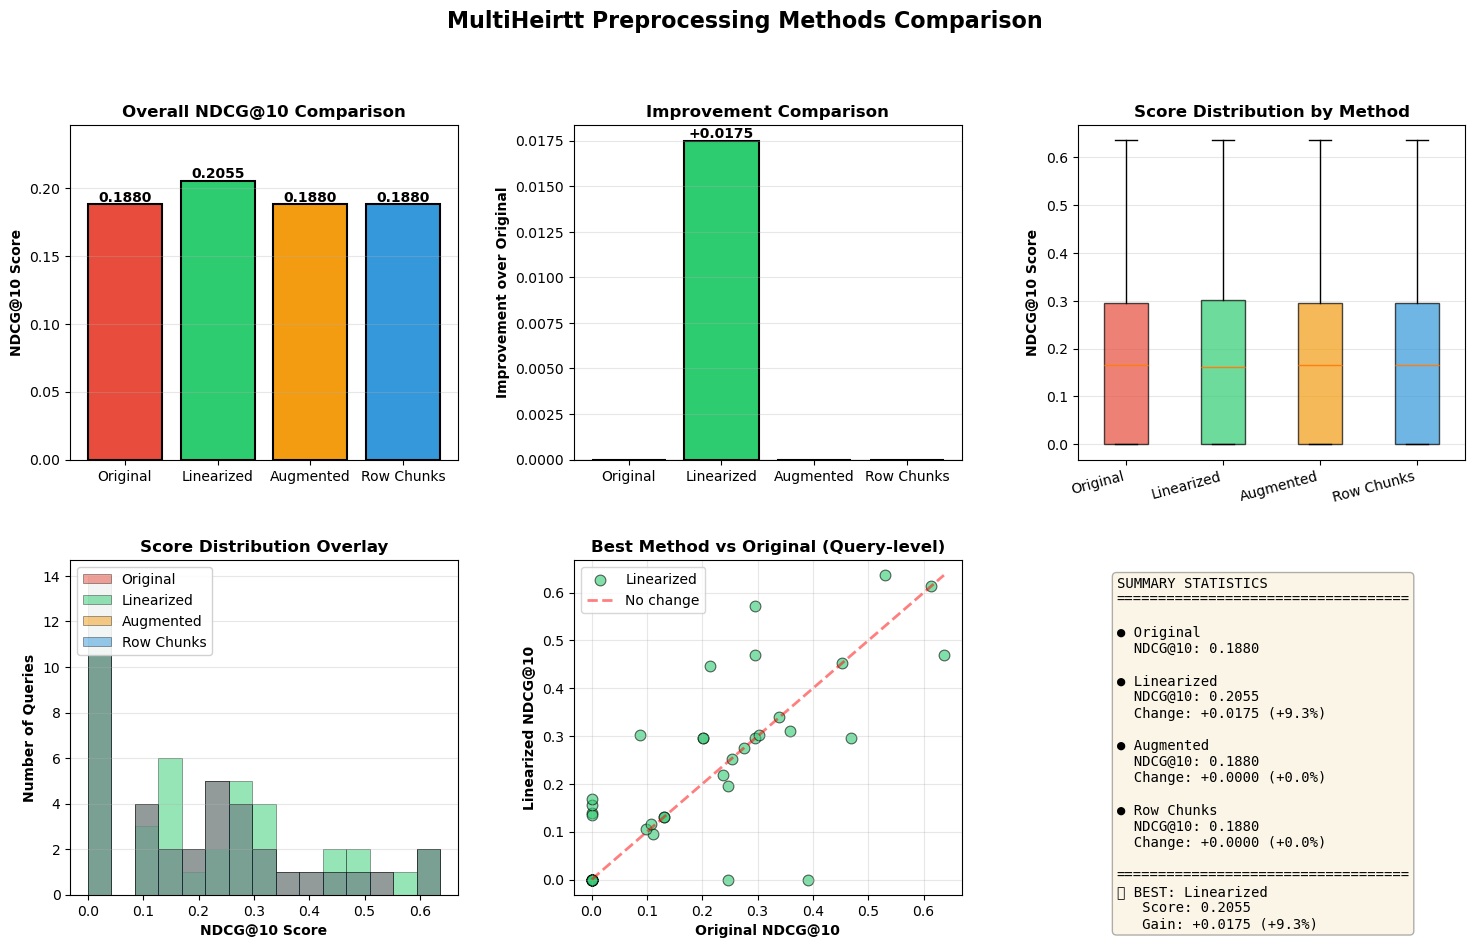


📁 Saved comprehensive visualization to: output\all_methods_comparison.png


In [42]:
# Comprehensive visualization: ALL methods
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Prepare data
methods = ['Original', 'Linearized', 'Augmented', 'Row Chunks']
ndcg_values = [
    ndcg_original,
    all_results['linearized']['ndcg_10'],
    all_results['augmented']['ndcg_10'],
    all_results['row_chunks']['ndcg_10']
]
colors = ['#e74c3c', '#2ecc71', '#f39c12', '#3498db']

# 1. Bar chart comparison
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(methods, ndcg_values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('NDCG@10 Score', fontweight='bold')
ax1.set_title('Overall NDCG@10 Comparison', fontweight='bold', fontsize=12)
ax1.set_ylim(0, max(ndcg_values) * 1.2)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, ndcg_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Improvement bar chart
ax2 = fig.add_subplot(gs[0, 1])
improvements = [0] + [v - ndcg_original for v in ndcg_values[1:]]
improvement_colors = [colors[0]] + [colors[i] if improvements[i] > 0 else '#e74c3c' 
                                     for i in range(1, len(improvements))]
bars2 = ax2.bar(methods, improvements, color=improvement_colors, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_ylabel('Improvement over Original', fontweight='bold')
ax2.set_title('Improvement Comparison', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars2, improvements):
    if val != 0:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{val:+.4f}', ha='center', va='bottom' if val > 0 else 'top', 
                 fontweight='bold')

# 3. Box plot - score distributions
ax3 = fig.add_subplot(gs[0, 2])
box_data = [
    results_original['ndcg_scores'],
    all_results['linearized']['ndcg_scores'],
    all_results['augmented']['ndcg_scores'],
    all_results['row_chunks']['ndcg_scores']
]
bp = ax3.boxplot(box_data, labels=methods, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('NDCG@10 Score', fontweight='bold')
ax3.set_title('Score Distribution by Method', fontweight='bold', fontsize=12)
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=15, ha='right')

# 4. Histogram overlay
ax4 = fig.add_subplot(gs[1, 0])
for scores, label, color in zip(box_data, methods, colors):
    ax4.hist(scores, bins=15, alpha=0.5, label=label, color=color, edgecolor='black', linewidth=0.5)
ax4.set_xlabel('NDCG@10 Score', fontweight='bold')
ax4.set_ylabel('Number of Queries', fontweight='bold')
ax4.set_title('Score Distribution Overlay', fontweight='bold', fontsize=12)
ax4.legend(loc='upper left', framealpha=0.9)
ax4.grid(axis='y', alpha=0.3)

# 5. Method-by-method scatter comparison
ax5 = fig.add_subplot(gs[1, 1])
# Compare best method vs original
best_idx = np.argmax(ndcg_values)
best_scores = box_data[best_idx]
original_scores = box_data[0]

ax5.scatter(original_scores, best_scores, alpha=0.6, s=60, 
           color=colors[best_idx], edgecolors='black', linewidth=0.8, label=methods[best_idx])
max_val = max(max(original_scores), max(best_scores))
ax5.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, linewidth=2, label='No change')
ax5.set_xlabel('Original NDCG@10', fontweight='bold')
ax5.set_ylabel(f'{methods[best_idx]} NDCG@10', fontweight='bold')
ax5.set_title(f'Best Method vs Original (Query-level)', fontweight='bold', fontsize=12)
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Summary statistics table
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

# Create summary table
summary_text = "SUMMARY STATISTICS\n" + "="*35 + "\n\n"
for method, ndcg, color in zip(methods, ndcg_values, colors):
    improvement = ndcg - ndcg_original
    improvement_pct = (improvement / ndcg_original * 100) if ndcg_original > 0 else 0
    
    summary_text += f"● {method}\n"
    summary_text += f"  NDCG@10: {ndcg:.4f}\n"
    if method != 'Original':
        summary_text += f"  Change: {improvement:+.4f} ({improvement_pct:+.1f}%)\n"
    summary_text += "\n"

# Best method highlight
summary_text += "="*35 + "\n"
summary_text += f"🏆 BEST: {methods[best_idx]}\n"
summary_text += f"   Score: {ndcg_values[best_idx]:.4f}\n"
if best_idx != 0:
    best_imp = ndcg_values[best_idx] - ndcg_original
    best_imp_pct = (best_imp / ndcg_original * 100)
    summary_text += f"   Gain: +{best_imp:.4f} (+{best_imp_pct:.1f}%)"

ax6.text(0.1, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('MultiHeirtt Preprocessing Methods Comparison', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig(OUTPUT_DIR / 'all_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📁 Saved comprehensive visualization to: {OUTPUT_DIR / 'all_methods_comparison.png'}")

In [43]:
# Detailed query-level analysis for BEST method
print("\n" + "="*70)
print("🔍 DETAILED ANALYSIS: BEST METHOD vs ORIGINAL")
print("="*70)

# Find best method
best_method_idx = np.argmax(ndcg_values)
best_method_name = methods[best_method_idx]

if best_method_idx == 0:
    print("\n⚠️ Original corpus is already the best (no improvement from preprocessing)")
else:
    print(f"\n🏆 Best method: {best_method_name}")
    
    # Get scores
    if best_method_name == 'Linearized':
        best_results = all_results['linearized']
    elif best_method_name == 'Augmented':
        best_results = all_results['augmented']
    else:  # Row Chunks
        best_results = all_results['row_chunks']
    
    # Calculate query-level improvements
    query_improvements = []
    for i in range(len(results_original['query_scores'])):
        orig_score = results_original['query_scores'][i]['ndcg']
        best_score = best_results['query_scores'][i]['ndcg']
        improvement = best_score - orig_score
        
        query_improvements.append({
            'query_id': results_original['query_scores'][i]['query_id'],
            'query_text': results_original['query_scores'][i]['query_text'],
            'original_ndcg': orig_score,
            'best_method_ndcg': best_score,
            'improvement': improvement
        })
    
    # Sort by improvement
    query_improvements.sort(key=lambda x: x['improvement'], reverse=True)
    
    # Statistics
    improvements_list = [q['improvement'] for q in query_improvements]
    better = sum(1 for imp in improvements_list if imp > 0)
    worse = sum(1 for imp in improvements_list if imp < 0)
    same = len(improvements_list) - better - worse
    
    print(f"\n📊 Query-level statistics:")
    print(f"   Better: {better} queries ({better/len(improvements_list)*100:.1f}%)")
    print(f"   Worse:  {worse} queries ({worse/len(improvements_list)*100:.1f}%)")
    print(f"   Same:   {same} queries ({same/len(improvements_list)*100:.1f}%)")
    
    # Top improved queries
    print("\n🟢 TOP 5 MOST IMPROVED QUERIES:")
    print("-"*70)
    for i, q in enumerate(query_improvements[:5], 1):
        print(f"{i}. Query: {q['query_text']}...")
        print(f"   Original: {q['original_ndcg']:.4f} → {best_method_name}: {q['best_method_ndcg']:.4f}")
        print(f"   Improvement: +{q['improvement']:.4f}")
        print()
    
    # Top worsened queries
    if worse > 0:
        print("\n🔴 TOP 5 MOST WORSENED QUERIES:")
        print("-"*70)
        for i, q in enumerate(query_improvements[-5:], 1):
            if q['improvement'] < 0:
                print(f"{i}. Query: {q['query_text']}...")
                print(f"   Original: {q['original_ndcg']:.4f} → {best_method_name}: {q['best_method_ndcg']:.4f}")
                print(f"   Change: {q['improvement']:.4f}")
                print()


🔍 DETAILED ANALYSIS: BEST METHOD vs ORIGINAL

🏆 Best method: Linearized

📊 Query-level statistics:
   Better: 13 queries (32.5%)
   Worse:  8 queries (20.0%)
   Same:   19 queries (47.5%)

🟢 TOP 5 MOST IMPROVED QUERIES:
----------------------------------------------------------------------
1. Query: What was the total amount of Square Feet-1 /Apartm...
   Original: 0.2961 → Linearized: 0.5724
   Improvement: +0.2763

2. Query: What's the sum of Unvested at December 31, 2018 of...
   Original: 0.2140 → Linearized: 0.4462
   Improvement: +0.2322

3. Query: What is the sum of Europe of Year Ended December 3...
   Original: 0.0875 → Linearized: 0.3026
   Improvement: +0.2151

4. Query: according to the above listed holders of common st...
   Original: 0.2961 → Linearized: 0.4693
   Improvement: +0.1732

5. Query: Which year is Equity securities in Carrying Value ...
   Original: 0.0000 → Linearized: 0.1681
   Improvement: +0.1681


🔴 TOP 5 MOST WORSENED QUERIES:
--------------------------

In [44]:
# Save comprehensive evaluation results
evaluation_results = {
    'summary': {
        'original_ndcg': float(ndcg_original),
        'linearized_ndcg': float(all_results['linearized']['ndcg_10']),
        'augmented_ndcg': float(all_results['augmented']['ndcg_10']),
        'rowchunks_ndcg': float(all_results['row_chunks']['ndcg_10']),
        'best_method': best_method_name,
        'best_score': float(ndcg_values[best_method_idx]),
        'num_queries_evaluated': len(results_original['ndcg_scores'])
    },
    'comparison_table': comparison_df.to_dict('records'),
    'method_scores': {
        'original': results_original['ndcg_scores'],
        'linearized': all_results['linearized']['ndcg_scores'],
        'augmented': all_results['augmented']['ndcg_scores'],
        'row_chunks': all_results['row_chunks']['ndcg_scores']
    }
}

# Add query-level improvements for best method if available
if best_method_idx != 0 and 'query_improvements' in locals():
    evaluation_results['best_method_query_analysis'] = query_improvements

import json
results_file = OUTPUT_DIR / 'all_methods_evaluation_results.json'
with open(results_file, 'w', encoding='utf-8') as f:
    json.dump(evaluation_results, f, indent=2, ensure_ascii=False)

print(f"\n📁 Saved evaluation results to: {results_file}")

# Also save comparison table as CSV
comparison_df.to_csv(OUTPUT_DIR / 'methods_comparison.csv', index=False)
print(f"📁 Saved comparison table to: {OUTPUT_DIR / 'methods_comparison.csv'}")

print("\n" + "="*70)
print("✅ COMPREHENSIVE EVALUATION COMPLETE!")
print("="*70)
print(f"\n📊 Summary:")
print(f"   Tested {len(methods)} methods on {len(queries_sample)} queries")
print(f"   Best method: {best_method_name} (NDCG@10: {ndcg_values[best_method_idx]:.4f})")
if best_method_idx != 0:
    improvement = ndcg_values[best_method_idx] - ndcg_original
    improvement_pct = (improvement / ndcg_original * 100)
    print(f"   Improvement: +{improvement:.4f} (+{improvement_pct:.1f}%)")
print("\n💡 Recommendation:")
if best_method_idx == 0:
    print("   Keep original corpus - preprocessing did not improve performance")
else:
    print(f"   Use '{best_method_name}' preprocessing for production")
print("="*70)


📁 Saved evaluation results to: output\all_methods_evaluation_results.json
📁 Saved comparison table to: output\methods_comparison.csv

✅ COMPREHENSIVE EVALUATION COMPLETE!

📊 Summary:
   Tested 4 methods on 40 queries
   Best method: Linearized (NDCG@10: 0.2055)
   Improvement: +0.0175 (+9.3%)

💡 Recommendation:
   Use 'Linearized' preprocessing for production
